In [1]:
# ── Cell 1：OrderBook 类定义 ──────────────────────────────────────────────────
_PRICE_SCALE = 1000

def _to_int_price(price):
    return round(price * _PRICE_SCALE)

def _to_float_price(int_price):
    return int_price / _PRICE_SCALE


class OrderBook:
    LEVELS = 10

    def __init__(self):
        self.bids = {}
        self.asks = {}
        self.last_price = 0.0
        self.cum_volume = 0
        self.cum_amount = 0.0
        self.timestamp  = 0
        self._bp1_int   = 0
        self._ap1_int   = 0
        self.bv1        = 0
        self.av1        = 0
        self.spread     = 0.0
        self.mid_price  = 0.0
        self.imbalance  = 0.0

    @property
    def bp1(self):
        return _to_float_price(self._bp1_int)

    @property
    def ap1(self):
        return _to_float_price(self._ap1_int)

    def _update_metrics(self):
        bid_empty = (self._bp1_int == 0)
        ask_empty = (self._ap1_int == 0)
        if bid_empty or ask_empty:
            self.spread    = float('nan')
            self.mid_price = float('nan')
        else:
            bp = self.bp1
            ap = self.ap1
            self.spread    = round(ap - bp, 6)
            self.mid_price = round((bp + ap) / 2, 6)
        total = self.bv1 + self.av1
        self.imbalance = round((self.bv1 - self.av1) / total, 6) if total > 0 else 0.0

    def init_from_snapshot(self, row):
        self.bids.clear()
        self.asks.clear()
        for i in range(1, self.LEVELS + 1):
            price = float(row[f'bp{i}'])
            vol   = int(row[f'bv{i}'])
            if vol > 0 and price > 0:
                self.bids[_to_int_price(price)] = vol
        for i in range(1, self.LEVELS + 1):
            price = float(row[f'ap{i}'])
            vol   = int(row[f'av{i}'])
            if vol > 0 and price > 0:
                self.asks[_to_int_price(price)] = vol
        self.last_price = float(row['last'])
        self.cum_volume = int(row['volume'])
        self.cum_amount = float(row['amount'])
        self.timestamp  = int(row.name)
        self._bp1_int   = _to_int_price(float(row['bp1']))
        self._ap1_int   = _to_int_price(float(row['ap1']))
        self.bv1        = int(row['bv1'])
        self.av1        = int(row['av1'])
        self._update_metrics()

    def apply_order(self, row):
        if str(getattr(row, 'order_type')) != 'limit':
            return
        side     = str(getattr(row, 'side'))
        int_p    = _to_int_price(float(getattr(row, 'price')))
        quantity = int(getattr(row, 'quantity'))
        if side == 'buy':
            self.bids[int_p] = self.bids.get(int_p, 0) + quantity
            if int_p > self._bp1_int:
                self._bp1_int = int_p
                self.bv1      = quantity
                self._update_metrics()
            elif int_p == self._bp1_int:
                self.bv1 += quantity
                self._update_metrics()
        else:
            self.asks[int_p] = self.asks.get(int_p, 0) + quantity
            if self._ap1_int == 0 or int_p < self._ap1_int:
                self._ap1_int = int_p
                self.av1      = quantity
                self._update_metrics()
            elif int_p == self._ap1_int:
                self.av1 += quantity
                self._update_metrics()
        self.timestamp = int(row.Index)

    def apply_trade(self, row):
        price    = float(getattr(row, 'price'))
        quantity = int(getattr(row, 'quantity'))
        int_p    = _to_int_price(price)
        if int_p <= self._bp1_int:
            book, hit_top, is_bid_side = self.bids, (int_p == self._bp1_int), True
        elif int_p >= self._ap1_int and self._ap1_int != 0:
            book, hit_top, is_bid_side = self.asks, (int_p == self._ap1_int), False
        else:
            bid_empty = (self._bp1_int == 0)
            ask_empty = (self._ap1_int == 0)
            if bid_empty and ask_empty:
                return
            elif bid_empty:
                book, hit_top, is_bid_side = self.asks, (int_p == self._ap1_int), False
            elif ask_empty:
                book, hit_top, is_bid_side = self.bids, (int_p == self._bp1_int), True
            else:
                dist_bid = int_p - self._bp1_int
                dist_ask = self._ap1_int - int_p
                if dist_bid <= dist_ask:
                    book, hit_top, is_bid_side = self.bids, (int_p == self._bp1_int), True
                else:
                    book, hit_top, is_bid_side = self.asks, (int_p == self._ap1_int), False
        top_cleared = False
        if int_p in book:
            book[int_p] = max(0, book[int_p] - quantity)
            if book[int_p] == 0:
                del book[int_p]
                top_cleared = hit_top
        self.last_price  = price
        self.cum_volume += quantity
        self.cum_amount += price * quantity
        if is_bid_side:
            if top_cleared:
                if self.bids:
                    self._bp1_int = max(self.bids)
                    self.bv1      = self.bids[self._bp1_int]
                else:
                    self._bp1_int, self.bv1 = 0, 0
            elif hit_top:
                self.bv1 = self.bids.get(self._bp1_int, 0)
        else:
            if top_cleared:
                if self.asks:
                    self._ap1_int = min(self.asks)
                    self.av1      = self.asks[self._ap1_int]
                else:
                    self._ap1_int, self.av1 = 0, 0
            elif hit_top:
                self.av1 = self.asks.get(self._ap1_int, 0)
        self._update_metrics()
        self.timestamp = int(row.Index)

    def to_snapshot(self):
        sorted_bids = sorted(self.bids.keys(), reverse=True)[:self.LEVELS]
        sorted_asks = sorted(self.asks.keys())[:self.LEVELS]
        result = {
            'timestamp':  self.timestamp,
            'last_price': self.last_price,
            'cum_volume': self.cum_volume,
            'cum_amount': round(self.cum_amount, 2),
            'spread':     self.spread,
            'mid_price':  self.mid_price,
            'imbalance':  self.imbalance,
        }
        for i in range(self.LEVELS):
            if i < len(sorted_bids):
                p = sorted_bids[i]
                result[f'bp{i+1}'] = _to_float_price(p)
                result[f'bv{i+1}'] = self.bids[p]
            else:
                result[f'bp{i+1}'] = 0.0
                result[f'bv{i+1}'] = 0
        for i in range(self.LEVELS):
            if i < len(sorted_asks):
                p = sorted_asks[i]
                result[f'ap{i+1}'] = _to_float_price(p)
                result[f'av{i+1}'] = self.asks[p]
            else:
                result[f'ap{i+1}'] = 0.0
                result[f'av{i+1}'] = 0
        return result

print('✓ OrderBook 类定义完成')

✓ OrderBook 类定义完成


In [2]:
# ── Cell 2：DataLoader 类定义 ─────────────────────────────────────────────────
import os
import pandas as pd

_EVENT_PRIORITY = {'order': 0, 'trade': 1}


class DataLoader:
    def __init__(self, clean_dir):
        self.clean_dir   = clean_dir
        self._df_level2  = None
        self._df_order   = None
        self._df_trade   = None

    def _lazy_load(self, attr, filename):
        if getattr(self, attr) is None:
            path = os.path.join(self.clean_dir, filename)
            df   = pd.read_parquet(path, engine='pyarrow')
            setattr(self, attr, df)
            print(f'[DataLoader] {filename} 已加载：{len(df):,} 行')
        return getattr(self, attr)

    @property
    def level2(self):
        return self._lazy_load('_df_level2', 'level2.parquet')

    @property
    def order(self):
        return self._lazy_load('_df_order', 'order.parquet')

    @property
    def trade(self):
        return self._lazy_load('_df_trade', 'trade.parquet')

    def find_anchor(self, t_target):
        df  = self.level2
        idx = df.index.searchsorted(t_target, side='right') - 1
        if idx < 0:
            raise ValueError(f'找不到锚点：t_target={t_target} 早于最早时间 {df.index[0]}')
        return df.iloc[idx]

    def get_events(self, t_start, t_end):
        df_o     = self.order
        df_order = df_o.loc[(df_o.index > t_start) & (df_o.index <= t_end)].copy()
        df_order['event_type'] = 'order'
        df_t     = self.trade
        df_trade = df_t.loc[(df_t.index > t_start) & (df_t.index <= t_end)].copy()
        df_trade['event_type'] = 'trade'
        combined = pd.concat([df_order, df_trade], axis=0, sort=False)
        if combined.empty:
            return combined
        combined['_time']     = combined.index
        combined['_priority'] = combined['event_type'].map(_EVENT_PRIORITY)
        if 'seq_no' in combined.columns:
            combined['_seq'] = combined['seq_no'].fillna(float('inf'))
            sort_keys = ['_time', '_seq', '_priority']
        else:
            sort_keys = ['_time', '_priority']
        combined.sort_values(sort_keys, kind='stable', inplace=True)
        combined.set_index('_time', inplace=True)
        combined.index.name = 'time'
        drop_cols = ['_priority']
        if '_seq' in combined.columns:
            drop_cols.append('_seq')
        combined.drop(columns=drop_cols, inplace=True)
        return combined

print('✓ DataLoader 类定义完成')

✓ DataLoader 类定义完成


In [3]:
# ── Cell 3：环境配置 & 初始化 ─────────────────────────────────────────────────
import time

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

CLEAN_DIR = os.path.join(os.path.expanduser('~'), 'Desktop', 'my-first-project', 'clean_data')

loader = DataLoader(CLEAN_DIR)
ob     = OrderBook()

print(f'CLEAN_DIR: {CLEAN_DIR}')
print('✓ loader 和 ob 初始化完成')

CLEAN_DIR: /Users/chongjidelaoshu/Desktop/my-first-project/clean_data
✓ loader 和 ob 初始化完成


In [4]:
# ── Cell 4：寻找时空锚点 ──────────────────────────────────────────────────────
T_TARGET = 93501000   # 目标时间戳，例如 09:35:00.000

anchor = loader.find_anchor(T_TARGET)
ob.init_from_snapshot(anchor)

print(f'目标时间   T_target : {T_TARGET}')
print(f'底座时间   T_start  : {ob.timestamp}')
print(f'距目标时间           : {T_TARGET - ob.timestamp} ms')

[DataLoader] level2.parquet 已加载：4,802 行
目标时间   T_target : 93501000
底座时间   T_start  : 93500000
距目标时间           : 1000 ms


In [5]:
# ── Cell 5：提取与检查流水 ────────────────────────────────────────────────────
T_START = ob.timestamp
events  = loader.get_events(T_START, T_TARGET)

print(f'流水总笔数：{len(events):,}')
print('\n── head(10) ──')
print(events.head(10))
print('\n── tail(10) ──')
print(events.tail(10))
print(f'\n时间戳严格单调递增：{events.index.is_monotonic_increasing}')
print('\nevent_type 分布：')
print(events['event_type'].value_counts())

[DataLoader] order.parquet 已加载：7,728 行
[DataLoader] trade.parquet 已加载：2,070 行
流水总笔数：3

── head(10) ──
              date     symbol  side  price  quantity order_type event_type
time                                                                      
93500166  20240207  SH.510050  sell 2.9420       300     market      order
93500972  20240207  SH.510050   buy 2.9350       300       stop      order
93500992  20240207  SH.510050   buy 2.9340       200       stop      order

── tail(10) ──
              date     symbol  side  price  quantity order_type event_type
time                                                                      
93500166  20240207  SH.510050  sell 2.9420       300     market      order
93500972  20240207  SH.510050   buy 2.9350       300       stop      order
93500992  20240207  SH.510050   buy 2.9340       200       stop      order

时间戳严格单调递增：True

event_type 分布：
event_type
order    3
Name: count, dtype: int64


In [6]:
# ── Cell 6：重放流水，重建盘口 ────────────────────────────────────────────────
t0 = time.time()

for row in events.itertuples():
    if row.event_type == 'order':
        ob.apply_order(row)
    elif row.event_type == 'trade':
        ob.apply_trade(row)

elapsed_ms = (time.time() - t0) * 1000
print(f'重放完成：{len(events):,} 笔流水，耗时 {elapsed_ms:.2f} ms')
print(f'平均每笔：{elapsed_ms / max(len(events), 1):.4f} ms')

重放完成：3 笔流水，耗时 0.64 ms
平均每笔：0.2137 ms


In [7]:
# ── Cell 7：对比验证 ──────────────────────────────────────────────────────────
reconstructed = ob.to_snapshot()

df_l2    = loader.level2
idx      = df_l2.index.searchsorted(T_TARGET, side='right') - 1
official = df_l2.iloc[idx] if idx >= 0 else None

compare_fields = (
    [f'bp{i}' for i in range(1, 11)] + [f'bv{i}' for i in range(1, 11)] +
    [f'ap{i}' for i in range(1, 11)] + [f'av{i}' for i in range(1, 11)]
)

print('\n' + '═' * 60)
print(f'  重建盘口 vs 官方快照（T = {T_TARGET}）')
print('═' * 60)
print(f'{"字段":<12}{"重建值":>16}{"官方值":>16}{"是否一致":>10}')
print('─' * 60)

for field in compare_fields:
    rec_val = reconstructed.get(field, 'N/A')
    off_val = float(official[field]) if official is not None else 'N/A'
    match   = '✓' if isinstance(rec_val, (int, float)) and isinstance(off_val, float) \
                     and abs(rec_val - off_val) < 1e-4 else '✗'
    print(f'{field:<12}{str(rec_val):>16}{str(round(off_val, 4)):>16}{match:>10}')

print('─' * 60)
for key in ['spread', 'mid_price', 'imbalance', 'last_price', 'cum_volume', 'cum_amount']:
    print(f'{key:<12}{str(reconstructed[key]):>16}')


════════════════════════════════════════════════════════════
  重建盘口 vs 官方快照（T = 93501000）
════════════════════════════════════════════════════════════
字段                       重建值             官方值      是否一致
────────────────────────────────────────────────────────────
bp1                    2.942           2.942         ✓
bp2                    2.941           2.941         ✓
bp3                     2.94            2.94         ✓
bp4                    2.939           2.939         ✓
bp5                    2.938           2.938         ✓
bp6                    2.937           2.937         ✓
bp7                    2.936           2.936         ✓
bp8                    2.935           2.935         ✓
bp9                    2.934           2.934         ✓
bp10                   2.933           2.933         ✓
bv1                     3600          3600.0         ✓
bv2                     1900          1900.0         ✓
bv3                      300           300.0         ✓
bv4              

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/var/folders/lw/r43mq0294q31nlkkxjs3z8kr0000gn/T/ipykernel_47413/2555168286.py:38: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lw/r43mq0294q31nlkkxjs3z8kr0000gn/T/ipykernel_474

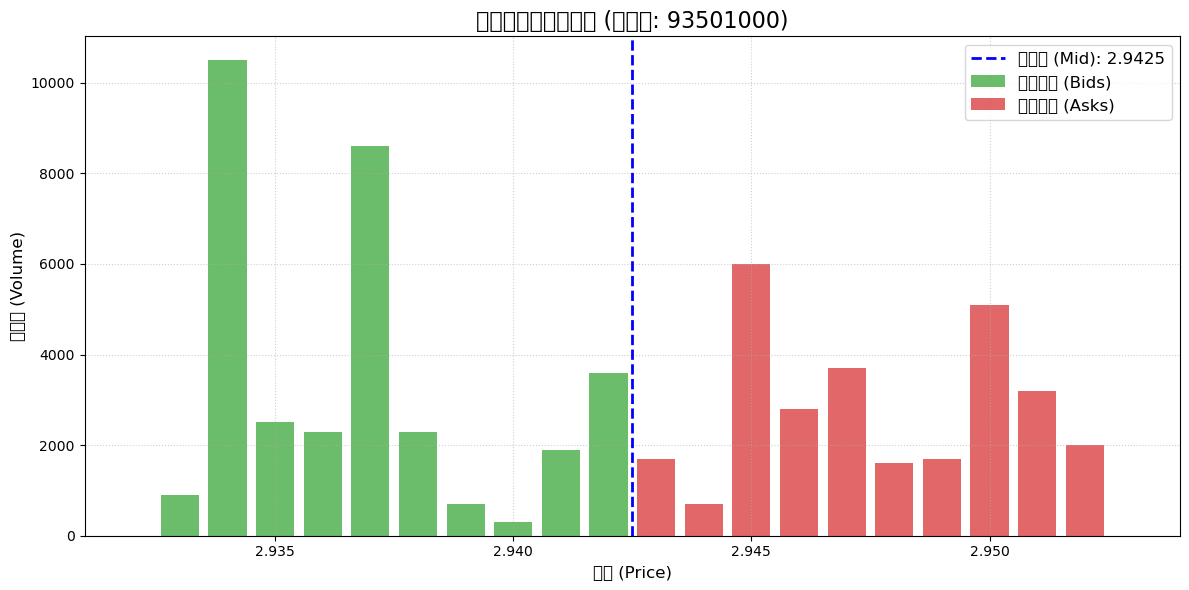

In [8]:
# ── Cell 7：盘口深度可视化 ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

# 解决图表中文显示问题（如果是 Mac 系统，将 SimHei 换成 Arial Unicode MS）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 1. 从你的字典中提取 10 档价格和数量
# 注意：买盘价格是降序的（从高到低），卖盘价格是升序的（从低到高）
bid_prices = [reconstructed[f"bp{i}"] for i in range(1, 11)]
bid_vols   = [reconstructed[f"bv{i}"] for i in range(1, 11)]

ask_prices = [reconstructed[f"ap{i}"] for i in range(1, 11)]
ask_vols   = [reconstructed[f"av{i}"] for i in range(1, 11)]

# 2. 开始画图
plt.figure(figsize=(12, 6))

# 使用柱状图展示每个价位的挂单量 (width 取决于你的 tick_size，这里暂设为 0.001)
plt.bar(bid_prices, bid_vols, color='#2ca02c', alpha=0.7, width=0.0008, label='买盘挂单 (Bids)')
plt.bar(ask_prices, ask_vols, color='#d62728', alpha=0.7, width=0.0008, label='卖盘挂单 (Asks)')

# 画一条中间价 (Mid-Price) 的基准线
mid_price = reconstructed['mid_price']
plt.axvline(x=mid_price, color='blue', linestyle='--', linewidth=2, label=f'中间价 (Mid): {mid_price}')

# 图表美化
plt.title(f"订单簿十档深度快照 (时间戳: {T_TARGET})", fontsize=16)
plt.xlabel("价格 (Price)", fontsize=12)
plt.ylabel("挂单量 (Volume)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# 自动调整 X 轴范围，让图表看起来更紧凑
all_prices = bid_prices + ask_prices
plt.xlim(min(all_prices) - 0.002, max(all_prices) + 0.002)

plt.tight_layout()
plt.show()